# 🛒 DigiStore E-Commerce Satış Analizi

**Tələbə:** Xətai Mehrəliyev  
**Müəllim:** Möhtərəm Ağayeva  
**Alətlər:** Pandas-Numpy-Matplotlib-Seaborn-Scipy-Plotly



##  Layihə Haqqında

Bu notebook "DigiStore" onlayn mağazasının satış datasinin 
Python ilə analizinə həsr olunub.  
Data "Oracle Live SQL"dən CSV formatında export edilib və 
pandas ilə yüklənib.

### Məqsəd
- Kateqoriya və region üzrə satış performansını analiz etmək
- Aylıq satış trendini müəyyən etmək
- Müştəri seqmentlərini müqayisə etmək
- Endirim təsirini ölçmək
- RFM analizi ilə müştəriləri seqmentləşdirmək

## 1️⃣ Kitabxanaların yüklənməsi

Analizdə istifadə olunacaq bütün Python kitabxanaları
notebook-un əvvəlində bir yerdə import edilir.

| Kitabxana  |  İstifadə Məqsədi            |
|----------- |---------------------------   |
| pandas     | Cədvəl və data əməliyyatları |
| numpy      | Riyazi hesablamalar          |
| matplotlib | Qrafik çəkmək                |
| seaborn    | Gözəl vizualizasiyalar       |
| plotly     | İnteraktiv vizualizasiyalar  |
| scipy      | Statistik hesablamalar       |



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px
from scipy import stats

warnings.filterwarnings('ignore')         # lazımsız xəbərdarlıq mesajlarını gizlədir. 
plt.rcParams['figure.figsize'] = (12, 6)  # plt.rcParams` — bütün qrafiklər üçün standart ölçü və şrift təyin edir.
plt.rcParams['font.size'] = 12             
sns.set_theme(style="whitegrid")          # sns.set_theme` — qrafiklərə vahid vizual stil verir.

print(" ✅Kitabxanalar yükləndi!")

 ✅Kitabxanalar yükləndi!


## 2️⃣ "CSV"lərin yüklənməsi
Bütün data Oracle Live SQL-də işlədilmiş sorğuların 
nəticələri CSV formatında export edilib və 
pandas `read_csv()` funksiyası ilə yüklənib.


        **PATH dəyişəni haqqında qeyd:**  
 PATH qovluğun tam ünvanını saxlayır. Hər CSV yüklənərkən  
 PATH + "fayl_adı.csv" birləşməsi tam fayl yolunu əmələ gətirir.  
 Bu yanaşma kodu qısa saxlayır — qovluq dəyişərsə yalnız  
 PATH-i yeniləmək kifayətdir.

In [5]:
# CSV fayllarının saxlandığı qovluğun yolu
PATH = r"C:\Users\user\Desktop\Layihe_CODEWORLD\Data\\"

# SQL sorğularının nəticələri CSV kimi yüklənir
s1 = pd.read_csv(PATH + "s1_category_sales.csv")       # Kateqoriya üzrə satış  
s2 = pd.read_csv(PATH + "s2_monthly_trend.csv")        # Aylıq satış trendi
s3 = pd.read_csv(PATH + "s3_top10_customers.csv")      # Top 10 müştəri
s4 = pd.read_csv(PATH + "s4_region_crosstab.csv")      # Region üzrə cross-tab
s5 = pd.read_csv(PATH + "s5_segment_avg.csv")          # Seqment üzrə orta dəyər
s6 = pd.read_csv(PATH + "s6_top_products.csv")         # Kateqoriyada ən çox satılan məhsul
s7 = pd.read_csv(PATH + "s7_discount_analysis.csv")    # Endirim faizinə görə satış
s8 = pd.read_csv(PATH + "s8_return_analysis.csv")      # İadə analizi
# Bonus sorğu nəticələri
b1 = pd.read_csv(PATH + "b1_running_total.csv")        # Kumulyativ satış
b2 = pd.read_csv(PATH + "b2_clv.csv")                  # Müştəri Lifetime Value
b3 = pd.read_csv(PATH + "b3_profit_margin.csv")        # Profit margin analizi

print(" ✅Bütün CSV-lər yükləndi!")

 ✅Bütün CSV-lər yükləndi!


## 3️⃣Sütunlar

| Cədvəl | Sütunlar |
|---|---|
| S1 | CATEGORY, TOTAL_AMOUNT, AVG_ORDER_AMOUNT |
| S2 | YEAR_MONTH, TOTAL_SALES |
| S3 | CUSTOMER_NAME, SUM_AMOUNT |
| S4 | REGION, ELECTRONICS, CLOTHING, HOME, BOOKS, SPORTS |
| S5 | SEGMENT, AVG_TOTAL_AMOUNT |
| S6 | CATEGORY, PRODUCT_NAME, SUM_QUANTITY, RN |
| S7 | DISCOUNT_GROUP, TOTAL_QUANTITY, TOTAL_AMOUNT |
| S8 | CATEGORY, RETURN_COUNT |
| B1 | ORDER_ID, PRODUCT_NAME, RUNNING_TOTAL |
| B2 | CUSTOMER_NAME, CUSTOMER_ID, XERCELDIYI_MEBLEG, SIFARIS_SAYI, CUMULATIVE_COUNT |
| B3 | PRODUCT_ID, PRODUCT_NAME, MENFEET_MARJASI, SATIS_SAYI, SATIS_MEBLEGI, MARGIN_GROUP |


---

### P1 — Satış paylanması (Distribution) analizi

**İstifadə olunan kitabxana:** matplotlib  
**Data:** S1 — Kateqoriya üzrə satış

**Qrafiklər:**
- **Bar chart** — hər kateqoriyanın ümumi satışını müqayisə edir
- **Boxplot** — satış dəyərlərinin yayılmasını, median və kənar dəyərləri göstərir

**Nəticə:**
- Electronics kateqoriyası ümumi satışda lider mövqedədir (1,577,059 AZN)
- Books kateqoriyası ən aşağı satış həcminə malikdir (57,999 AZN)
- Boxplot-da Electronics outlier kimi görünür,
  digər kateqoriyalardan əhəmiyyətli dərəcədə yüksəkdir

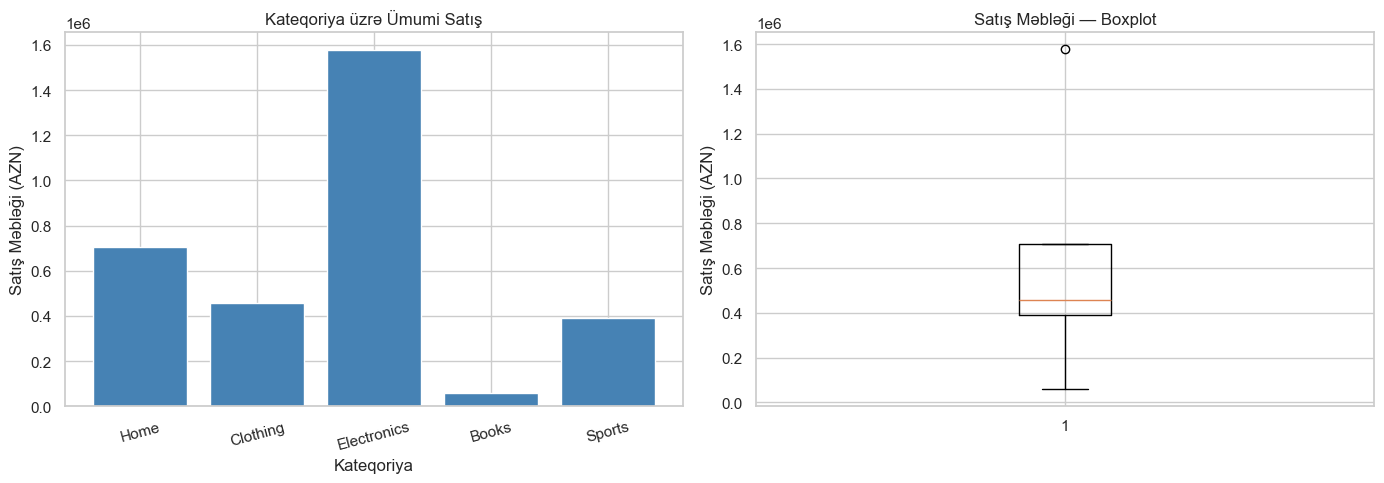

In [7]:
# Yan-yana 2 qrafik pəncərəsi yaradır — en:14, hündürlük:5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol qrafik — Bar chart: kateqoriya üzrə ümumi satış
axes[0].bar(s1['CATEGORY'], s1['TOTAL_AMOUNT'],       # X oxu — kateqoriya adları, Y oxu — hər kateqoriyanın ümumi satışı
            color='steelblue', edgecolor='white')     # Mavi sütunlar, ağ kənar
axes[0].set_title('Kateqoriya üzrə Ümumi Satış')      # Başlıq
axes[0].set_xlabel('Kateqoriya')                      # X oxu adı
axes[0].set_ylabel('Satış Məbləği (AZN)')             # Y oxu adı
axes[0].tick_params(axis='x', rotation=15)            # X adlarını 15 dərəcə əyir

# Sağ qrafik — Boxplot: satış məbləğinin yayılması
# Minimum, Q1, Median, Q3, Maksimum və outlier-ləri göstərir
axes[1].boxplot(s1['TOTAL_AMOUNT'])                   # TOTAL_AMOUNT sütununa bax
axes[1].set_title('Satış Məbləği — Boxplot')          # Başlıq
axes[1].set_ylabel('Satış Məbləği (AZN)')             # Y oxu adı

plt.tight_layout()                                    # Qrafiklər üst-üstə düşməsin
plt.show()                                            # Qrafiki ekranda göstər

---



### P2 — Kateqoriya üzrə Satış Müqayisəsi

**İstifadə olunan kitabxana:** seaborn, matplotlib  
**Data:** S1 — Kateqoriya üzrə satış

**Qrafiklər:**
- **Bar chart** — kateqoriyaları satış həcminə görə müqayisə edir
- **Pie chart** — hər kateqoriyanın ümumi satışdakı faiz payını göstərir

**Nəticə:**
- Electronics kateqoriyası ümumi satışın 49.4%-ni təşkil edir
- Books kateqoriyası ən aşağı payda — cəmi 1.8%
- Şirkətin gəlirinin əsas hissəsi Electronics və 
  Home kateqoriyalarından gəlir

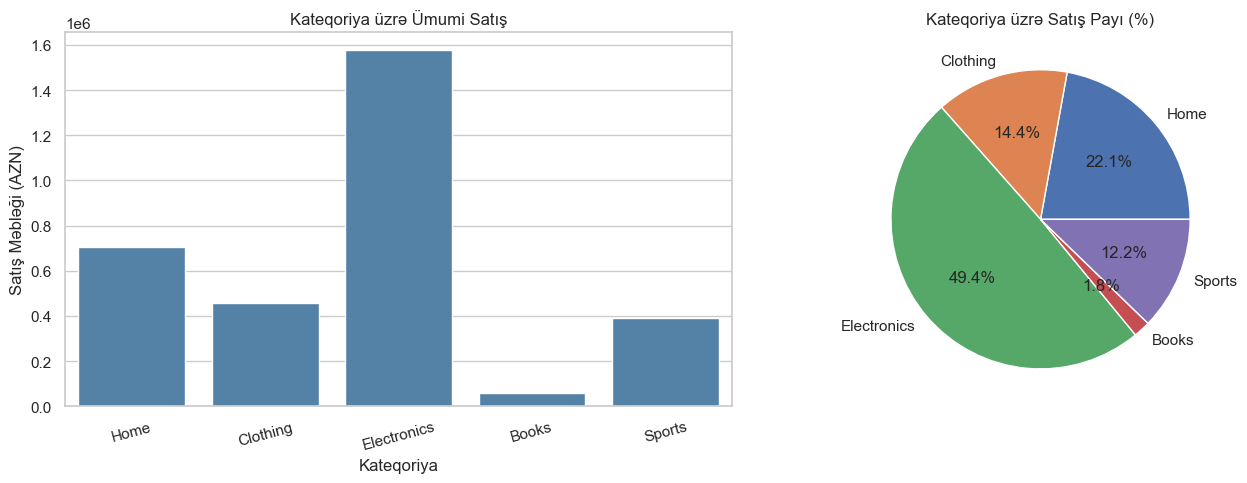

In [8]:
# Yan-yana 2 qrafik pəncərəsi yarat — en:14, hündürlük:5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol qrafik — Bar chart: kateqoriya üzrə satış müqayisəsi
sns.barplot(data=s1,                                       # s1 datasından istifadə edir
            x='CATEGORY',                                  # X oxu — kateqoriya adları
            y='TOTAL_AMOUNT',                              # Y oxu — satış məbləğləri
            ax=axes[0],                                    # Sol qrafikə çək
            color='steelblue')                             # Sütunların rəngi
axes[0].set_title('Kateqoriya üzrə Ümumi Satış')           # Başlıq
axes[0].set_xlabel('Kateqoriya')                           # X oxu adı
axes[0].set_ylabel('Satış Məbləği (AZN)')                  # Y oxu adı
axes[0].tick_params(axis='x', rotation=15)                 # X adlarını 15 dərəcə əyilt

# Sağ qrafik — Pie chart: hər kateqoriyanın satışdakı faiz payı
axes[1].pie(s1['TOTAL_AMOUNT'],                            # Hər dilimin böyüklüyü üçün satış məbləğindən istifadə edir
            labels=s1['CATEGORY'],                         # Dilimlərin adları
            autopct='%1.1f%%')                             # Hər dilimdə faiz göstər     
axes[1].set_title('Kateqoriya üzrə Satış Payı (%)')        # Başlıq

plt.tight_layout()                                         # Qrafiklər üst-üstə düşməsin
plt.show()                                                 # Qrafiki ekranda göstər



---


### P3 — Aylıq Trend Analizi və Hərəkətli Orta

**İstifadə olunan kitabxana:** pandas, matplotlib  
**Data:** S2 — Aylıq satış trendi

**Qrafiklər:**
- **Line chart** — 2 il ərzində aylıq satışın gedişatını göstərir
- **Hərəkətli orta xətti (H_ORTA3)** — 3 aylıq hərəkətli orta, 
  kəskin dalğalanmaları hamarlaşdırır və əsas trendi aydın göstərir

**Nəticə:**
- Noyabr-Dekabr aylarında satış kəskin artır — mövsümi effekt
- 2024-cü ildə ümumi trend 2023-cü ilə nisbətən yüksəkdir
- Hərəkətli orta xətti göstərir ki, satışda sabit artım trendi var

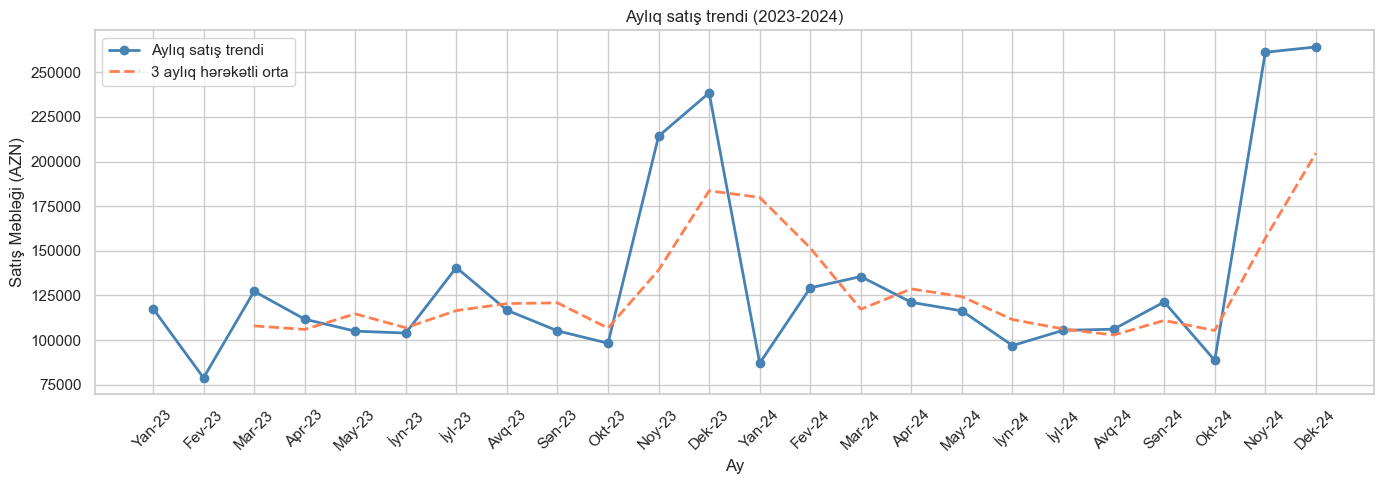

In [9]:
# 3 aylıq hərəkətli orta hesabla — hər nöqtə üçün özündən əvvəlki 3 ayın ortası
s2['H_ORTA3'] = s2['TOTAL_SALES'].rolling(window=3).mean()

# X oxu üçün qısa ay adları — 24 ay (2023-2024)
ay_adlari = ['Yan-23','Fev-23','Mar-23','Apr-23','May-23','İyn-23',
             'İyl-23','Avq-23','Sən-23','Okt-23','Noy-23','Dek-23',
             'Yan-24','Fev-24','Mar-24','Apr-24','May-24','İyn-24',
             'İyl-24','Avq-24','Sən-24','Okt-24','Noy-24','Dek-24']

# Tək qrafik pəncərəsi yarat — en:14, hündürlük:5
fig, ax = plt.subplots(figsize=(14, 5))

# Aylıq satış xətti
ax.plot(ay_adlari,                     # X oxu — ay adları
        s2['TOTAL_SALES'],             # Y oxu — hər ayın satış məbləği
        color='steelblue',             # Xəttin rəngi
        marker='o',                    # Hər nöqtədə dairə işarəsi
        linewidth=2,                   # Xəttin qalınlığı
        label='Aylıq satış trendi')    # Legend üçün ad


# 3 aylıq hərəkətli orta xətti
ax.plot(ay_adlari,                      # X oxu — ay adları
        s2['H_ORTA3'],                  # Y oxu — hərəkətli orta dəyərləri
        color='coral',                  # Narıncı rəng
        linewidth=2,                    # Xəttin qalınlığı
        linestyle='--',                 # Kəsik-kəsik xətt 
        label='3 aylıq hərəkətli orta') # Legend üçün ad

ax.set_title('Aylıq satış trendi (2023-2024)')          # Başlıq
ax.set_xlabel('Ay')                                     # X oxu adı
ax.set_ylabel('Satış Məbləği (AZN)')                    # Y oxu adı
ax.tick_params(axis='x', rotation=45)                   # X adlarını 45 dərəcə əyilt
ax.legend()                                             # Legend göstər

plt.tight_layout()
plt.show()

---




### P4 — Korrelyasiya Analizi (Endirim vs Satış)

**İstifadə olunan kitabxana:** seaborn, matplotlib  
**Data:** S7 — Endirim faizinə görə satış performansı

**Qrafiklər:**
- **Scatter plot** — endirim faizi ilə satış məbləği 
  arasındakı əlaqəni göstərir
- **Heatmap** — endirim və satış məbləği arasındakı 
  korrelyasiyanı göstərir

**Nəticə:**
- Endirim və satış arasında mənfi korrelyasiya var (-0.68) — 
  endirim artdıqca satış məbləği azalır
- Endirimsiz (0%) satışlar ən yüksək həcmdədir — 1,900,000 AZN
- Şirkət endirim kampaniyalarının effektivliyini 
  yenidən qiymətləndirməlidir

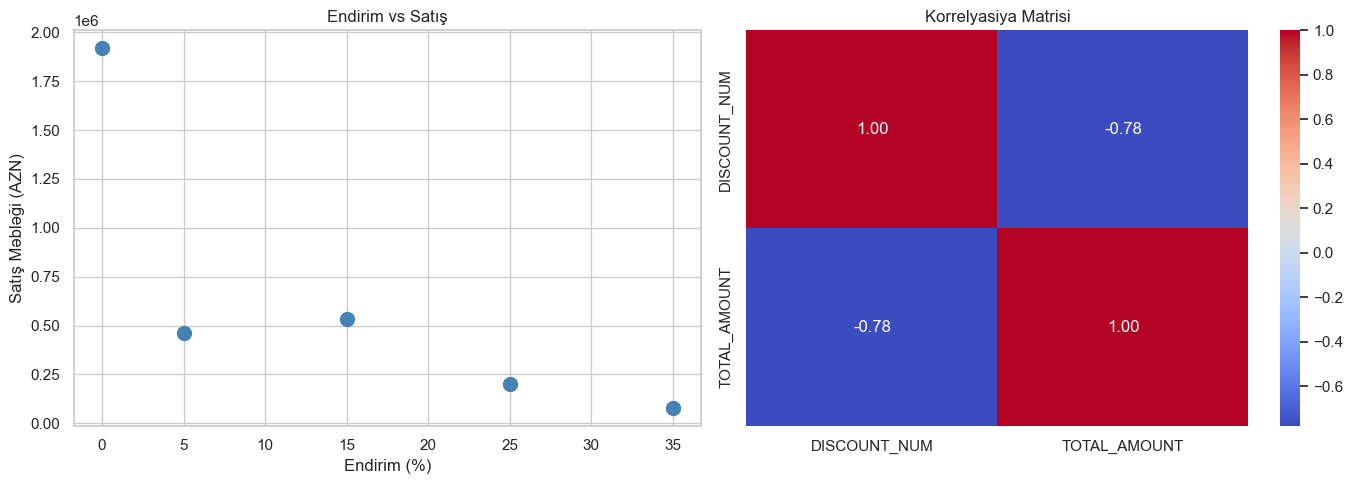

In [10]:
# Yan-yana 2 qrafik pəncərəsi yaradır — en:14, hündürlük:5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Endirim qruplarını mətndən → ədədə çevirir (korrelyasiya üçün ədədi dəyər lazımdır)
endirim_map = {'0%': 0, '1-10%': 5, '11-20%': 15,'21-30%': 25, '31-40%': 35}
# Hər qrup üçün aralığın ortası götürülür: 1-10% → 5, 11-20% → 15, 21-30% → 25, 31-40% → 35
s7['DISCOUNT_NUM'] = s7['DISCOUNT_GROUP'].map(endirim_map)              # Yeni sütun yaradır


# Sol qrafik — Scatter plot: endirim vs satış əlaqəsi
axes[0].scatter(s7['DISCOUNT_NUM'], s7['TOTAL_AMOUNT'],
                color='steelblue', s=100)                                # "s=100" nöqtə ölçüsü
axes[0].set_title('Endirim vs Satış')                                    # Başlıq
axes[0].set_xlabel('Endirim (%)')                                        # X oxu adı
axes[0].set_ylabel('Satış Məbləği (AZN)')                                # Y oxu adı


# Endirim və satış arasındakı korrelyasiya matrisini hesablayır
corr = s7[['DISCOUNT_NUM', 'TOTAL_AMOUNT']].corr()


# Sağ qrafik — Heatmap: korrelyasiya matrisini rəngli göstər
sns.heatmap(corr, annot=True,                                            # Hər xanada dəyər göstər
            fmt='.2f',                                                   # 2 onluq rəqəm              
            cmap='coolwarm',                                             # Mənfi=mavi, müsbət=qırmızı           
            ax=axes[1])                                                  # Sağ qrafikə çək

axes[1].set_title('Korrelyasiya Matrisi')                                # Başlıq



plt.tight_layout()
plt.show()




---



### P5 — Regionlar üzrə Müqayisəli Analiz

**İstifadə olunan kitabxana:** pandas, matplotlib  
**Data:** S4 — Region və kateqoriya üzrə cross-tab

**Qrafik:**
- **Grouped bar chart** — hər regionun kateqoriya üzrə 
  satışını yan-yana müqayisə edir

**Nəticə:**
- Bakı bütün kateqoriyalarda ən yüksək satışa malikdir
- Sirvan ən aşağı satış həcminə malik regiondur
- Electronics hər regionda dominant kateqoriyadır

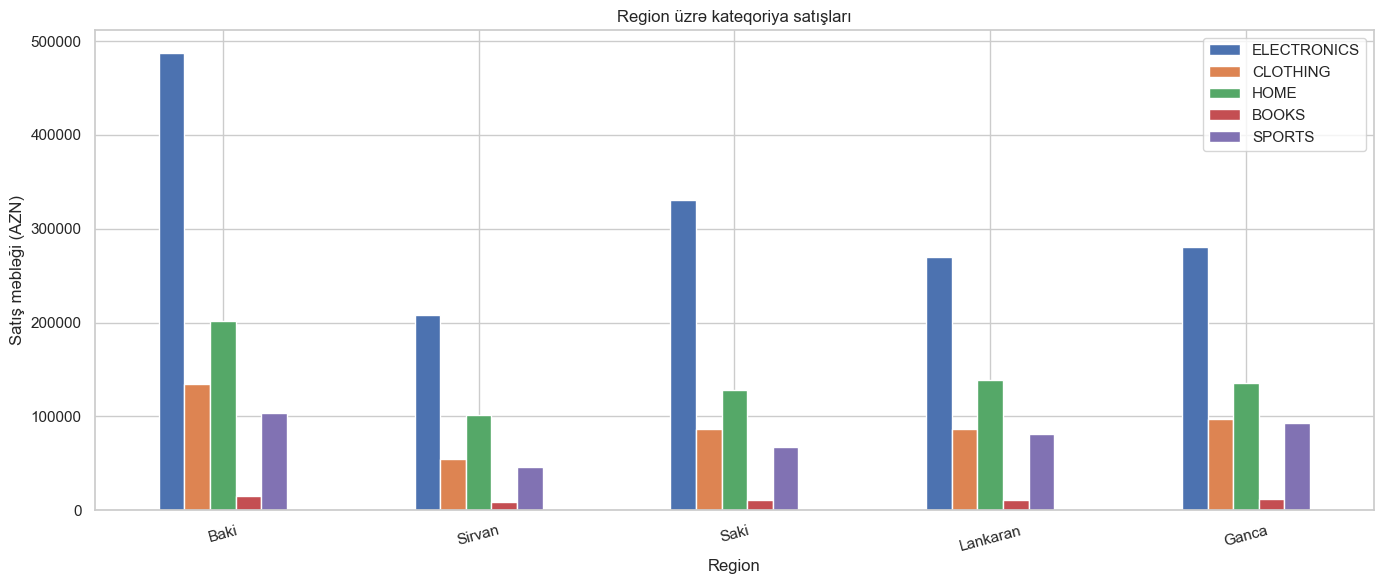

In [11]:
# qrafik pəncərəsi yaradır — en:14, hündürlük:6
fig, ax = plt.subplots(figsize=(14, 6)) 

#REGION sütununu X oxuna çevirir, kateqoriyaları yan-yana bar kimi çəkir
s4.set_index('REGION').plot(kind='bar', ax=ax) 

ax.set_title('Region üzrə kateqoriya satışları')          # qrafik baslığını təyin edir
ax.set_xlabel('Region')                                   # X oxunun adını təyin edir
ax.set_ylabel('Satış məbləği (AZN)')                      # Y oxunun adını təyin edir
ax.tick_params(axis='x', rotation=15)                     # X oxundakı region adlarını 15 dərəcə əyir
ax.legend()                                               # kateqoriya rəngləri barədə məlumat verən legend əlavə edir

plt.tight_layout()                                        # Qrafik elementlərinin üst-üstə düşməyinin qarsısın alır
plt.show()                                                # qrafiki ekranda göstərir





---

### A1 — Müştəri Seqmentasiyası (RFM Analizi)

**İstifadə olunan kitabxana:** pandas  
**Data:** rfm_data.csv — Tamamlanmış sifarişlər əsasında

RFM analizi müştəriləri 3 göstərici əsasında qiymətləndirir:

| Göstərici     | İzah                       | Bal Meyarı               |
|---|---|---|
| Recency (R)   | Son alışdan neçə gün keçib | Az gün → yüksək bal      |
| Frequency (F) | Neçə dəfə alış edib        | Çox sifariş → yüksək bal |
| Monetary (M)  | Nə qədər pul xərcləyib     | Çox pul → yüksək bal     |

Hər göstərici 1-3 arası ballanır, birləşdirilərək RFM skoru yaradılır.
Sonra hər müştəri skoruna görə seqmentə aid edilir.

**Seqment Nəticələri:**

| Seqment | Müştəri Sayı | Təsvir |
|---|---|---|
| Potential | 214 | Yaxın alır, amma az sifariş sayı var |
| At Risk   | 29  | Müddət keçib, uzaqlaşma riski var    |
| Champion  | 7   | Ən yaxşı müştərilər                  |
| Lost      | 5   | Artıq alış-veriş etmir               |
| Loyal     | 1   | Az amma sadiq müştəri                |

**Əsas Nəticə:**
- Müştərilərin 83%-i Potential seqmentindədir — 
  tez-tez almırlar, amma yaxın vaxtda alıblar
- Champion müştərilər yalnız 7 nəfərdir — 
  onlara xüsusi loyallıq proqramı tövsiyə edilir
- 29 At Risk müştəri üçün təcili kampaniya lazımdır

In [12]:
# RFM analizi üçün xam datanı yükləyir
rfm = pd.read_csv(PATH + "rfm_data.csv")
print(rfm.head())                          # İlk 5 sətiri göstər — yükləməni yoxla
print(rfm.shape)                           # Sətir və sütun sayını göstər

   CUSTOMER_ID     CUSTOMER_NAME       LAST_ORDER_DATE  FREQUENCY  MONETARY
0            1   Leyla Mammadova  2024-12-25T00:00:00Z         60  76121.57
1            2     Rasad Quliyev  2024-12-15T00:00:00Z          6  15812.95
2            3     Nigar Aliyeva  2024-06-29T00:00:00Z          6   5002.62
3            4     Orxan Babayev  2024-09-02T00:00:00Z          6   3482.15
4            5  Gunel Ismayilova  2024-12-02T00:00:00Z          6   9910.29
(256, 5)


---

In [13]:
# LAST_ORDER_DATE sütununu tarix formatına çevir, timezone məlumatını sil
# (Live SQL export zamanı əlavə olunan UTC timezone-u aradan qaldırır)
rfm['LAST_ORDER_DATE'] = pd.to_datetime(
    rfm['LAST_ORDER_DATE'], utc=True).dt.tz_localize(None)

# Datasetin son tarixi — Recency hesablamaq üçün referans nöqtəsi
today = pd.Timestamp('2024-12-31')

# Hər müştərinin son sifarişindən bu günə qədər neçə gün keçdiyini hesabla
# Az gün = müştəri yaxın vaxtda alış edib = yaxşı müştəri

rfm['RECENCY'] = (today - rfm['LAST_ORDER_DATE']).dt.days
# Nəticəni yoxla — ilk 5 müştərinin R, F, M dəyərləri
print(rfm[['CUSTOMER_NAME', 'RECENCY', 'FREQUENCY', 'MONETARY']].head())

      CUSTOMER_NAME  RECENCY  FREQUENCY  MONETARY
0   Leyla Mammadova        6         60  76121.57
1     Rasad Quliyev       16          6  15812.95
2     Nigar Aliyeva      185          6   5002.62
3     Orxan Babayev      120          6   3482.15
4  Gunel Ismayilova       29          6   9910.29


---

###  RFM Skorlarının Hesablanması

Hər müştəriyə R, F, M üzrə 1-3 arası bal verilir.
Sonra 3 bal birləşdirilərək RFM skoru yaradılır.

In [14]:
# 4. RFM skorları


# 1) Recency skorunu hesablayır — Son sifaris tarixindən 0-177 gün kecibsə      '3' yəni yüksək bal
#                                                      177-354 gün kecibsə      '2' yəni orta   bal
#                                                      354-531 gün kecibsə      '1' yƏni aşağı  bal verir.
rfm['R'] = pd.cut(rfm['RECENCY'],
                  bins=[0, 177, 354, 531],
                  labels=[3, 2, 1])
# 2) Frequency skorunu hesablayır- Müştəri             5-26 sayda  sifariş veribsə  1 yəni aşağı
#                                                      26-43 sayda sifaris veribsə  2 yəni orta
#                                                      43-60 sayda sifaris veribsə  3 yəni yüksək bal verir.
rfm['F'] = pd.cut(rfm['FREQUENCY'],
                  bins=[5, 26, 43, 60],
                  labels=[1, 2, 3])
# 3) Monetary skorunu hesablayır - Müştəri             1137-26000  AZN dəyərində sifaris veribsə 1 yəni aşağı
#                                                      26000-51000 AZN dəyərində sifaris veribsə 2 yəni orta
#                                                      51000-76122 AZN dəyərində sifaris veribsə 3 yəni yüksək bal verir
rfm['M'] = pd.cut(rfm['MONETARY'],
                  bins=[1137, 26000, 51000, 76122],
                  labels=[1, 2, 3])

# 4) RFM skoru
# R, F, M ballarını birləşdirib hər müştəriyə RFM skoru verir
rfm['RFM_SCORE'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

# İlk 10 müştərinin RFM skorlarını göstərir 
print(rfm[['CUSTOMER_NAME', 'R', 'F', 'M', 'RFM_SCORE']].head(10))

      CUSTOMER_NAME  R  F  M RFM_SCORE
0   Leyla Mammadova  3  3  3       333
1     Rasad Quliyev  3  1  1       311
2     Nigar Aliyeva  2  1  1       211
3     Orxan Babayev  3  1  1       311
4  Gunel Ismayilova  3  1  1       311
5     Tural Nasirov  3  3  3       333
6   Aynur Huseynova  3  1  1       311
7    Kamran Ahmadov  3  1  1       311
8     Sevda Rzayeva  3  1  1       311
9  Farid Mustafayev  3  1  1       311


In [15]:
# RFM skoruna görə müştəri seqmentini təyin edən funksiya
def rfm_segment(score):
    
    # Bütün ballar 3 — ən yaxşı müştəri
    if score == '333':
        return 'Champion'
    
    # R=3 (yaxın), F=2 və ya 3 (tez-tez alır) — sadiq müştəri
    elif score[0] == '3' and score[1] in ['2', '3']:
        return 'Loyal'
    
    # R=3 (yaxın), F=1 (az alır) — potensial müştəri
    elif score[0] == '3' and score[1] == '1':
        return 'Potential'
    
    # R=2 (orta müddət) — risk altında olan müştəri
    elif score[0] == '2':
        return 'At Risk'
    
    # Qalan hamısı — artıq alış-veriş etmir
    else:
        return 'Lost'

# Hər müştərinin RFM skoruna funksiyanı tətbiq edir, SEGMENT sütunu yaradır
rfm['SEGMENT'] = rfm['RFM_SCORE'].apply(rfm_segment)

# Hər seqmentdə neçə müştəri varsa göstərir
print(rfm['SEGMENT'].value_counts())

SEGMENT
Potential    214
At Risk       29
Champion       7
Lost           5
Loyal          1
Name: count, dtype: int64


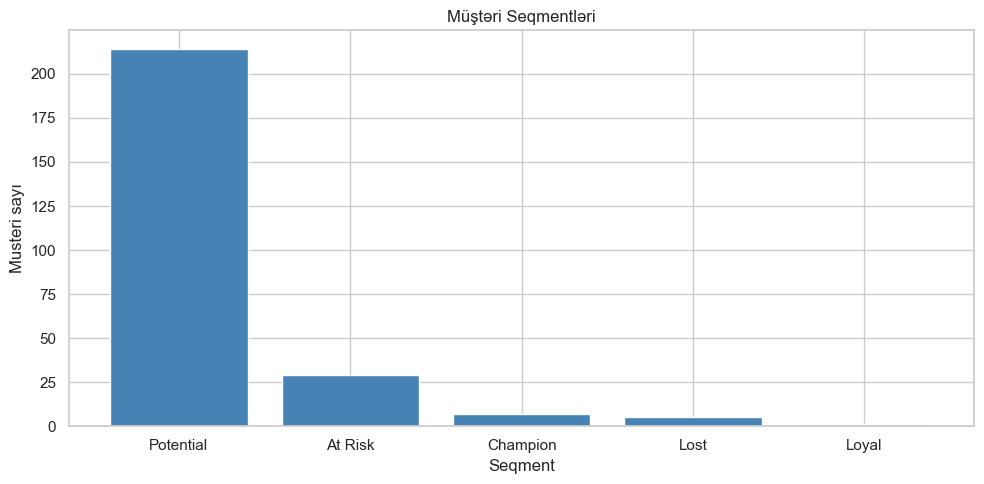

In [16]:
# Tək qrafik pəncərəsi yarat — en:10, hündürlük:5
fig,ax= plt.subplots(figsize=(10,5))

# Hər seqmentdə neçə müştəri olduğunu say
segment_counts=rfm['SEGMENT'].value_counts()

# Bar chart: seqment adları X oxunda, müştəri sayı Y oxunda
ax.bar(segment_counts.index,             # X oxu — seqment adları
       segment_counts.values,            # Y oxu — müştəri sayları
       color='steelblue')


ax.set_xlabel('Seqment')                 # X oxu adı
ax.set_ylabel('Musteri sayı')            # Y oxu adı
ax.set_title('Müştəri Seqmentləri')      # Başlıq 
plt.tight_layout()
plt.show()